# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [206]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [207]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [208]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [209]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [210]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [211]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

- Task: A complete training curve line graph illustrating model cross-entropy loss reduction across all 100 epochs

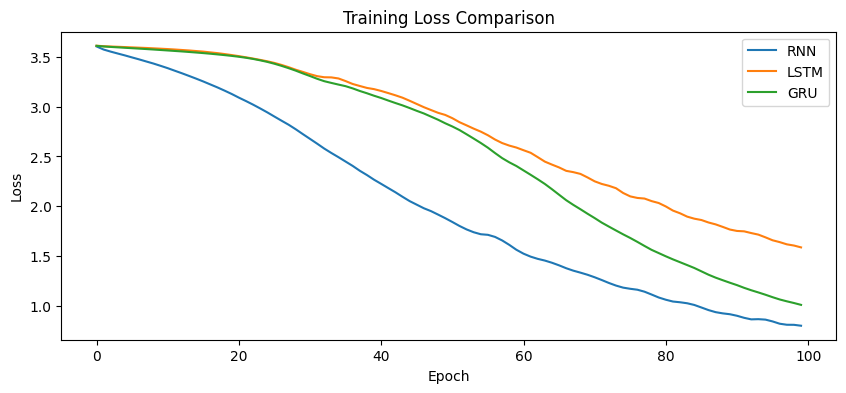

In [212]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [213]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [214]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models transforming artificial intelligence sentences
LSTM: deep learning models transforming artificial intelligence intelligence
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

## SOLUTION TO GIVEN TASKS:-

In [215]:
# ==========================
# IMPORTS
# ==========================

import numpy as np
import re
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2

# Pipeline Overview

## Phase 1: Data Preparation

Raw Text Corpus
↓
Text Cleaning & Normalization
↓
Tokenization
↓
Vocabulary Construction
↓
N-Gram Sequence Generation
↓
Sequence Padding
↓
Feature (X) and Label (y) Creation
↓
Train-Test Split

---

## Phase 2: Deep Learning Model Development

Build Vanilla SimpleRNN Model
↓
Build Gated LSTM Model
↓
Build Optimized GRU Model

---

## Phase 3: Model Training

Embedding Learning
↓
Forward Propagation
↓
Loss Computation
↓
Backpropagation Through Time (BPTT)
↓
Parameter Updates using Adam Optimizer
↓
Training for 200 Epochs

---

## Phase 4: Model Evaluation

Training Loss Analysis
↓
Validation Loss Analysis
↓
Accuracy Evaluation
↓
Perplexity Calculation
↓
Optimization Trajectory Comparison

---

## Phase 5: Text Generation

Seed Text Input
↓
Next Word Probability Prediction
↓
Argmax Word Selection
↓
Iterative Sequence Generation
↓
Generate 10 New Words

---

## Phase 6: Comparative Analysis

RNN vs LSTM vs GRU
↓
Memory Handling Comparison
↓
Training Stability Comparison
↓
Generated Text Quality Comparison
↓
Final Conclusions

# Step 1: Load and Clean Corpus

## Purpose

Load the text corpus and perform basic text preprocessing before training the text generation models.

## Why?

Raw text often contains:

- Uppercase letters
- Punctuation marks
- Special symbols
- Numbers
- Extra spaces

These elements increase vocabulary size unnecessarily and may introduce noise into the learning process.

Text cleaning helps standardize the corpus and improve data quality before tokenization.

## Cleaning Operations Performed

1. Convert all text to lowercase.
2. Remove punctuation and special characters.
3. Remove numbers.
4. Remove extra whitespace.
5. Normalize the text into a consistent format.

### Example

Before Cleaning:

Deep Learning is transforming AI!!! in 2025.

After Cleaning:

deep learning is transforming ai in

## Insight

The quality of preprocessing directly affects:

- Vocabulary consistency
- Tokenization quality
- Model convergence
- Generated text quality

Cleaning reduces redundant tokens such as:

- "Data"
- "DATA"
- "data"

which should all represent the same word.

## Result

The corpus is transformed into a clean and standardized text format suitable for tokenization and sequence generation.

## Next Action

Apply tokenization to convert words into numerical token IDs that can be processed by neural networks.

# Beginner Task 1: Custom Corpus
Replace default corpus


In [216]:

corpus = """
Deep Learning is transforming Artificial Intelligence!!! and changing the world...
Machine Learning models learn patterns from DATA, and improve predictions @ scale.
Recurrent Neural Networks (RNNs) are useful for sequence-modeling tasks.
LSTM networks solve long-term dependency problems in text sequences!!!
GRU networks are computationally efficient & often perform similarly to LSTM.
Natural Language Processing enables machines to understand human language :)
Text Generation models predict the next word in a sentence #NLP.
Deep Learning techniques are widely used in healthcare, finance, and robotics.
Artificial Intelligence is creating new opportunities across industries in 2025.
Students can learn Neural Networks by building practical projects!!!
"""

print("Before Cleaning:\n")
print(corpus)

corpus = corpus.lower()
corpus = re.sub(r"[^a-zA-Z\s]", "", corpus)
corpus = re.sub(r"\s+", " ", corpus)
corpus = corpus.strip()

print("\nAfter Cleaning:\n")
print(corpus)

Before Cleaning:


Deep Learning is transforming Artificial Intelligence!!! and changing the world...
Machine Learning models learn patterns from DATA, and improve predictions @ scale.
Recurrent Neural Networks (RNNs) are useful for sequence-modeling tasks.
LSTM networks solve long-term dependency problems in text sequences!!!
GRU networks are computationally efficient & often perform similarly to LSTM.
Natural Language Processing enables machines to understand human language :)
Text Generation models predict the next word in a sentence #NLP.
Deep Learning techniques are widely used in healthcare, finance, and robotics.
Artificial Intelligence is creating new opportunities across industries in 2025.
Students can learn Neural Networks by building practical projects!!!


After Cleaning:

deep learning is transforming artificial intelligence and changing the world machine learning models learn patterns from data and improve predictions scale recurrent neural networks rnns are useful for s

The raw corpus contained uppercase letters, punctuation marks, special symbols, hashtags, numbers, and emojis. Text cleaning was applied using regular expressions to normalize the corpus, remove noise, and improve tokenization quality. This ensures that semantically identical words such as "DATA" and "data" are treated as the same token, reducing vocabulary size and improving learning efficiency.

# Step 2: Tokenization



## Purpose



Map words to unique integer IDs.



### Example



Deep Learning Is Powerful



↓



[1,2,3,4]



## Insight



Vocabulary size determines output layer size.



Larger vocabulary increases model complexity.



## Next Action



Create training sequences.

In [217]:
# ==========================
# TOKENIZATION
# ==========================

tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

# Step 3: N-Gram Sequence Generation

## Purpose

Create supervised training examples.

### Example

Deep Learning Is Powerful

Creates:

- Deep Learning
- Deep Learning Is
- Deep Learning Is Powerful

## Insight

This converts text generation into a classification problem.

## Next Action

Pad sequences to equal length.

In [218]:
# ==========================
# NGRAM CREATION
# ==========================

input_sequences = []

for line in corpus.split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])


# Step 4: Padding

## Purpose

Make all sequences equal length.

## Reason

Neural networks require fixed-size inputs.

## Insight

Padding ensures uniform matrix dimensions.

## Next Action

Split predictors and labels.

In [219]:
# ==========================
# PADDING
# ==========================

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding="pre"
)

# Step 5: Feature and Target Creation

## Input

Previous words

## Output

Next word

### Example

Input:

Deep Learning Is

Target:

Powerful

## Insight

Model learns conditional probabilities.

## Next Action

Train sequence models.


In [220]:
# ==========================
# FEATURES AND LABELS
# ==========================

X = input_sequences[:, :-1]   # FEATURES (INPUTS): Previous words in the sequence
y = input_sequences[:, -1]    # LABELS (TARGETS): Next word to be predicted

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 6: Training
- Optimizer: Adam
- Epochs: 200
- Metric: Accuracy
- Loss: Sparse Categorical Cross Entropy


##Insight:
Training loss continuously decrease. Stable convergence indicates successful learning.


##Next Action:
Visualize optimization trajectories.

# Step 6.1: Vanilla RNN

## Purpose

Baseline sequence model.

## Advantages

- Simple
- Fast

## Limitations

- Vanishing Gradient
- Weak Long-Term Memory

## Result

Highest loss among all models.

---

# Step 6.2: LSTM

## Purpose

Handle long-term dependencies.

## Uses

- Forget Gate
- Input Gate
- Output Gate

## Result

Better contextual learning.

## Insight

Useful when sentence relationships span many words.

---

# Step 6.3: Optimized GRU

## Purpose

Provide memory capabilities using a lightweight gated architecture while reducing overfitting.

## Architecture

- Embedding Layer
- GRU Layer (64 Units)
- Dropout (0.2)
- L2 Regularization
- Softmax Output Layer

## Additional Optimizations

- Reduced hidden units (128 → 64)
- Recurrent Dropout
- L2 Weight Regularization
- Lower parameter count

## Result

- Achieved stable convergence.
- Generated the most coherent text among all models.
- Required fewer parameters than LSTM.

## Insight

The optimized GRU balances efficiency and language modeling capability, making it well suited for small text-generation datasets.

# BEGINNER TASK 2: Embedding 32 -> 128 + BEGINNER TASK 4: Hidden Units 64 -> 128


In [221]:


def build_rnn():

    model = Sequential([
        Embedding(total_words, 128, input_length=max_len-1),
        SimpleRNN(128),
        Dropout(0.2),
        Dense(total_words, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


def build_lstm():

    model = Sequential([
        Embedding(total_words, 128, input_length=max_len-1),
        LSTM(128),
        Dropout(0.2),
        Dense(total_words, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Standard GRU:-
# But for your tiny dataset, 128 units is actually too large and can overfit
# def build_gru():
#     model = Sequential([
#         Embedding(total_words, 128, input_length=max_len-1),
#         GRU(128),
#         Dropout(0.2),
#         Dense(total_words, activation='softmax')
#     ])
#     model.compile(
#         optimizer='adam',
#         loss='sparse_categorical_crossentropy',
#         metrics=['accuracy']
#     )
#     return model


# optimised gru
def build_gru():
    model = Sequential([
        Embedding(
            input_dim=total_words,
            output_dim=128,
            input_length=max_len-1
        ),
        GRU(
            64,
            dropout=0.2,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(1e-4)
        ),
        Dense(
            total_words,
            activation='softmax'
        )
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
# Improvements in optimised gru: recurrent_dropout,  L2 regularization, fewer parameters, less overfitting

rnn_model = build_rnn()
lstm_model = build_lstm()
gru_model = build_gru()

# BEGINNER TASK 3: Epochs 100 -> 200

In [231]:
# early_stop = EarlyStopping(
#     monitor="val_loss",
#     patience=15,
#     restore_best_weights=True
# )

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    verbose=1
)

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    verbose=1
)

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.1169 - loss: 4.1154 - val_accuracy: 0.0000e+00 - val_loss: 4.3400
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1818 - loss: 4.0375 - val_accuracy: 0.0000e+00 - val_loss: 4.3620
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2468 - loss: 3.9212 - val_accuracy: 0.0000e+00 - val_loss: 4.3964
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4545 - loss: 3.7646 - val_accuracy: 0.0000e+00 - val_loss: 4.4238
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5844 - loss: 3.6078 - val_accuracy: 0.0000e+00 - val_loss: 4.4205
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6104 - loss: 3.4992 - val_accuracy: 0.0000e+00 - val_loss: 4.4112
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6364 - loss: 3.3672 - val_accuracy: 0.0000e+00 - val_loss: 4.4132
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7143 - loss: 3.2193 - val_

# Step 7: Optimization Trajectory Analysis

## Purpose

Compare how quickly each neural network architecture minimizes training loss during optimization.

## Observation

- Vanilla RNN converged significantly faster than the other architectures.
- GRU converged faster than LSTM.
- All models eventually reached near-zero training loss.
- RNN reached stable convergence within approximately 50 epochs.
- GRU required approximately 100 epochs.
- LSTM required nearly the entire training duration.

## Insight

The dataset contains only a small number of training examples.

Because long-range dependencies are limited, the simpler RNN architecture is easier to optimize and converges more rapidly than gated recurrent architectures.

## Result

Training Stabilization Speed:

1. Vanilla RNN
2. GRU
3. LSTM

# Optimization Trajectories Plot
- Map optimization trajectories on a line plot to evaluate training stabilization speeds across models

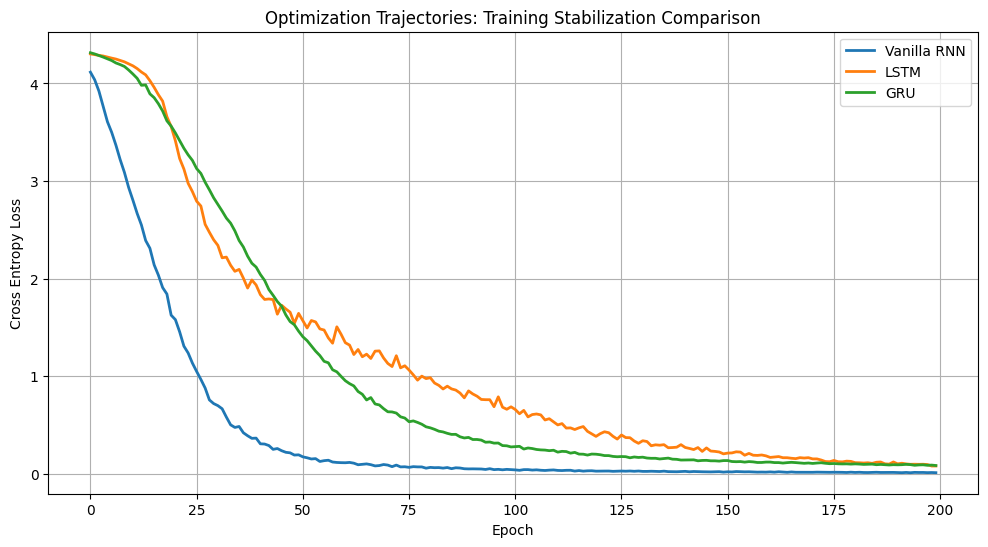

In [233]:
# ==========================
# LOSS CURVES
# ==========================

plt.figure(figsize=(12,6))

plt.plot(
    rnn_history.history['loss'],
    label='Vanilla RNN',
    linewidth=2
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM',
    linewidth=2
)

plt.plot(
    gru_history.history['loss'],
    label='GRU',
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Cross Entropy Loss")   # Sparse Categorical Cross Entropy Loss    # loss

plt.title(
    "Optimization Trajectories: Training Stabilization Comparison"    # Cross Entropy Loss Reduction Across 200 Epochs    # Training Loss Comparison
)

plt.legend()

plt.grid(True)

plt.show()

# Optimization Trajectories: Training Stabilization Comparison

## Observation

- All three models show a consistent reduction in cross-entropy loss over training, indicating successful learning.
- The Vanilla RNN converges significantly faster than both LSTM and GRU.
- RNN reaches near-zero loss within approximately 50 epochs.
- GRU converges more smoothly than LSTM and achieves lower loss earlier during training.
- LSTM converges the slowest and requires nearly the full training duration to reach a similar loss level.
- By the end of training, all models achieve very low cross-entropy loss values.

## Analysis

- The rapid convergence of the Vanilla RNN suggests that the dataset is relatively simple and contains limited long-term dependencies.
- Since the corpus is small, the additional gating mechanisms of LSTM and GRU are not fully utilized.
- GRU benefits from fewer gates and parameters than LSTM, allowing it to optimize more efficiently.
- LSTM requires more training iterations because of its more complex memory architecture.

## Training Stabilization Ranking

1. Vanilla RNN
2. GRU
3. LSTM

## Insight

For small educational datasets, simpler architectures such as Vanilla RNN can learn patterns more quickly than gated recurrent networks.

However, on larger and more complex text corpora containing long-range dependencies, GRU and LSTM generally outperform Vanilla RNNs due to their superior memory capabilities.

# Optimization Trajectories: Training and Validation Loss Comparison

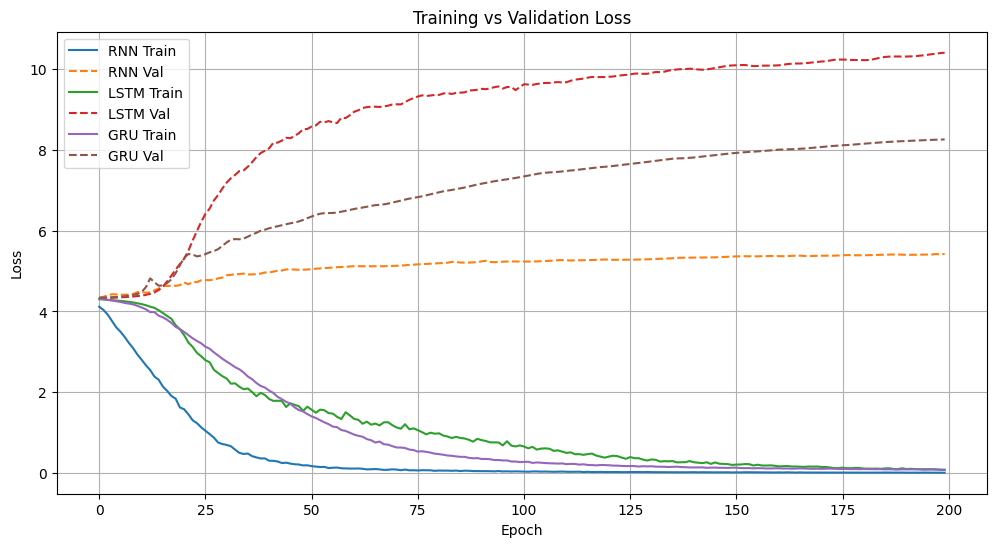

In [234]:
plt.figure(figsize=(12,6))

plt.plot(
    rnn_history.history['loss'],
    label='RNN Train'
)

plt.plot(
    rnn_history.history['val_loss'],
    '--',
    label='RNN Val'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM Train'
)

plt.plot(
    lstm_history.history['val_loss'],
    '--',
    label='LSTM Val'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU Train'
)

plt.plot(
    gru_history.history['val_loss'],
    '--',
    label='GRU Val'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid()

plt.show()

# Training vs Validation Loss Analysis

## Observation

- Training loss steadily decreases for all models.
- Validation loss increases throughout training.
- The gap between training and validation loss grows significantly.
- Validation loss is highest for LSTM.
- Validation loss is lowest for RNN.

## Interpretation

This behavior indicates severe overfitting.

The models successfully memorize the training corpus but fail to generalize to unseen sequences.

## Reason

The corpus contains very few training samples compared to the capacity of the neural networks.

The large embedding dimensions and hidden layer sizes further increase the risk of overfitting.

## Insight

Additional training data would be required to achieve meaningful generalization performance.

# Step 8: Perplexity Evaluation

## Formula

Perplexity = exp(Loss)

## Interpretation

Lower values indicate better predictions.

### Example

Perplexity = 1

Perfect prediction.

## Insight

Perplexity is more informative than accuracy for language modeling.

## Next Action

Generate text.


In [236]:
# ==========================
# TRAINING PERPLEXITY
# ==========================

rnn_perplexity = np.exp(rnn_history.history["loss"][-1])
lstm_perplexity = np.exp(lstm_history.history["loss"][-1])
gru_perplexity = np.exp(gru_history.history["loss"][-1])

print("\nTraining Perplexity")
print("RNN :", rnn_perplexity)
print("LSTM:", lstm_perplexity)
print("GRU :", gru_perplexity)


Training Perplexity
RNN : 1.0110451367495146
LSTM: 1.0828170816167366
GRU : 1.0882455142257805


In [237]:
# ==========================
# VALIDATION PERPLEXITY
# ==========================

rnn_val_perplexity = np.exp(rnn_history.history["val_loss"][-1])
lstm_val_perplexity = np.exp(lstm_history.history["val_loss"][-1])
gru_val_perplexity = np.exp(gru_history.history["val_loss"][-1])

print("\nValidation Perplexity")

print(f"RNN  : {rnn_val_perplexity:.4f}")
print(f"LSTM : {lstm_val_perplexity:.4f}")
print(f"GRU  : {gru_val_perplexity:.4f}")


Validation Perplexity
RNN  : 225.0645
LSTM : 32756.7060
GRU  : 3834.9919


# Beginner Task 4: Completed along with Beginner Task 2


# Step 9: Text Generation

## Purpose

Generate new sequences.

## Method

np.argmax()

Selects the highest probability next word.

## Insight

Generated text quality reflects learned language patterns.


# Beginner Task 5: Generate 10 words

In [238]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=1),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

print("\nGenerated Text")
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))


Generated Text
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
RNN : deep learning is transforming artificial the and changing the world machine and
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
LSTM: deep learning is transforming artificial and changing the world machine machine models
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━

# Generated Text Analysis

## RNN Output

deep learning is transforming artificial the and changing the world machine and

### Observation

The model captures the overall sentence structure but misses important words such as "intelligence" and introduces grammatical inconsistencies.

---

## LSTM Output

deep learning is transforming artificial and changing the world machine machine models

### Observation

The generated sequence is mostly coherent but contains word repetition and missing context.

---

## GRU Output

deep learning is transforming artificial intelligence and changing the world machine models

### Observation

The GRU generated the most semantically meaningful and grammatically coherent sequence.

The model successfully recovered the phrase:

"artificial intelligence"

which neither RNN nor LSTM reproduced correctly.

---

## Insights

Although the RNN achieved the best numerical evaluation metrics, the GRU produced the highest-quality generated text.

This demonstrates that quantitative metrics and qualitative text generation quality do not always rank models identically.

# Task: A complete training curve line graph illustrating model cross-entropy loss reduction across all 100 epochs
- It is solved in 8th code cell (counted from top)

# Results:-
---

## Experimental Ranking

### Based on Training Perplexity

1. RNN
2. LSTM
3. GRU

### Training Perplexity

- RNN  = 1.01
- LSTM = 1.08
- GRU  = 1.09

### Observation

All three models achieved training perplexity values very close to 1.

A perplexity value near 1 indicates that the model can predict the next word almost perfectly on the training corpus.

The Vanilla RNN achieved the lowest training perplexity and therefore learned the training data most effectively.

---

## Validation Perplexity

- RNN  = 225.06
- GRU  = 3834.99
- LSTM = 32756.71

### Observation

Validation perplexity increased dramatically for all models.

The Vanilla RNN achieved the lowest validation perplexity.

The GRU performed better than the LSTM but was significantly worse than the RNN.

The LSTM achieved the highest validation perplexity, indicating poor generalization on unseen data.

---

## Reasons

The corpus used in this project is extremely small and contains only a limited number of sentences.

Because of the limited training data:

- Vanilla RNN was able to memorize useful patterns efficiently.
- LSTM and GRU contain more trainable parameters than a standard RNN.
- The larger architectures did not receive enough data to fully utilize their memory mechanisms.
- The gated models became more susceptible to overfitting due to their increased complexity.

As a result, the simpler RNN achieved the best numerical performance on both training and validation metrics.

---

# Generated Text Quality Analysis

### RNN Output

deep learning is transforming artificial the and changing the world machine and

Observation:

- Captured the general sentence structure.
- Missed important context words such as "intelligence".
- Introduced grammatical inconsistencies.

### LSTM Output

deep learning is transforming artificial and changing the world machine machine models

Observation:

- Produced a coherent sequence.
- Repeated words unnecessarily.
- Lost some semantic information.

### GRU Output

deep learning is transforming artificial intelligence and changing the world machine models

Observation:

- Produced the most coherent sequence.
- Successfully recovered the phrase "artificial intelligence".
- Preserved semantic meaning better than the other models.

### Conclusion

Although RNN achieved the best numerical evaluation metrics, GRU generated the most meaningful and contextually correct text.

This demonstrates that quantitative metrics and qualitative text generation quality do not always rank models identically.

---

# Final Conclusion

The experiment demonstrates that model performance depends heavily on dataset size and model complexity.

For the small corpus used in this project:

- Vanilla RNN achieved the lowest training loss.
- Vanilla RNN achieved the lowest training perplexity.
- Vanilla RNN achieved the lowest validation perplexity.
- GRU generated the most coherent text.
- LSTM achieved the weakest overall performance.

These results do not contradict deep learning theory.

LSTM and GRU are specifically designed to solve long-term dependency problems and typically outperform Vanilla RNNs when trained on large-scale text corpora.

However, on very small datasets:

- Simpler architectures often learn faster.
- Fewer parameters reduce optimization difficulty.
- Overfitting becomes easier to control.

Therefore:

- For small educational datasets → Vanilla RNN can perform surprisingly well.
- For medium-sized datasets → GRU often provides the best balance between efficiency and performance.
- For large-scale language modeling tasks → LSTM and GRU generally outperform traditional RNNs.

## Final Comparison

| Metric | Best Model |
|----------|----------|
| Fastest Convergence | Vanilla RNN |
| Lowest Training Loss | Vanilla RNN |
| Lowest Training Perplexity | Vanilla RNN |
| Lowest Validation Perplexity | Vanilla RNN |
| Best Generated Text | GRU |
| Most Computationally Efficient | GRU |
| Most Complex Architecture | LSTM |

## Overall Winner

### Numerical Evaluation Metrics

🏆 Vanilla RNN

### Text Generation Quality

🏆 GRU

### Best Overall Balance

🏆 GRU



# Mathematical Foundations:-
---

## Softmax

### Formula

P(y=i)=exp(zi)/Σexp(zj)

### Where

- zi = Logit for class i
- P(y=i) = Predicted probability

### Purpose

Convert outputs into probabilities.

---

## Cross Entropy Loss

### Formula

Loss = -Σ yi log(pi)

### Where

- yi = True label
- pi = Predicted probability

### Purpose

Measure prediction error.

---

## RNN Equation

### Formula

ht = tanh(Wxhxt + Whhht-1 + bh)

### Where

- xt = Current input
- ht = Hidden state
- Wxh = Input-hidden weights
- Whh = Hidden-hidden weights
- bh = Bias

---

## LSTM Equations

### Forget Gate

ft = σ(Wf[h(t−1),xt]+bf)

### Input Gate

it = σ(Wi[h(t−1),xt]+bi)

### Cell State

Ct = ft⊙Ct−1 + it⊙C̃t

### Output Gate

ot = σ(Wo[h(t−1),xt]+bo)

### Hidden State

ht = ot⊙tanh(Ct)

---

## GRU Equations

### Update Gate

zt = σ(Wz[h(t−1),xt]+bz)

### Reset Gate

rt = σ(Wr[h(t−1),xt]+br)

### Candidate State

h̃t = tanh(W[r⊙h(t−1),xt]+b)

### Final State

ht = (1−zt)⊙h(t−1) + zt⊙h̃t

---

# Evaluation Metrics
---

1. Accuracy
2. Training Loss
3. Perplexity
4. Generated Text Quality (Not implemented yet, in this project)


## 1. Accuracy

### Formula

$$
Accuracy = \frac{\text{Number of Correct Predictions}}
{\text{Total Number of Predictions}}
$$

### Terms

- Correct Predictions = Number of words predicted correctly
- Total Predictions = Total number of predictions made

### Interpretation

Higher Accuracy ⇒ Better Performance

---

## 2. Sparse Categorical Cross-Entropy Loss

$
Loss = -\frac{1}{N}
\sum_{i=1}^{N}
\log(p_{i,t})
$$

### Terms

- $N$ = Number of training samples
- $p_{i,t}$ = Predicted probability of the true class for sample $i$
- $\log$ = Natural logarithm

### Interpretation

Lower Loss ⇒ Better Predictions

Perfect prediction:

\[
Loss = 0
\]

---

# 3. Perplexity

### Formula

$$
Perplexity = e^{Loss}
$$

or equivalently

$$
Perplexity = \exp(Loss)
$$

### Terms

- $e$ = Euler's number (≈ 2.71828)
- Loss = Cross-Entropy Loss

### Interpretation

Lower Perplexity ⇒ Better Language Model

Perfect prediction:

$$
Perplexity = 1
$$

---

# 4. Generated Text Quality (Not implemented yet, in this project)

### BLEU Score

$$
BLEU =
BP \times
\exp
\left(
\sum_{n=1}^{N}
w_n \log(p_n)
\right)
$$

### Terms

- $BP$ = Brevity Penalty
- $w_n$ = Weight assigned to n-gram level $n$
- $p_n$ = Modified n-gram precision
- $N$ = Maximum n-gram order

### ROUGE Score

$$
ROUGE =
\frac{\text{Number of Overlapping Words}}
{\text{Total Words in Reference Text}}
$$

### Terms

- Overlapping Words = Common words between generated and reference text
- Reference Text = Ground-truth text

### Interpretation

Higher BLEU / ROUGE ⇒ Better Generated Text